# Prédiction du prix de l'immobilier — Modèle M4
### XGBoost · Target Encoding · Optimisation Optuna

Ce notebook met en œuvre un modèle de régression pour prédire le prix de vente de maisons (jeu de données *House Prices*, Kaggle). L'approche s'articule autour de trois piliers :

1. un **feature engineering** orienté métier — gestion fine des valeurs manquantes et création de variables agrégées ;
2. un **prétraitement sans fuite de données**, reconstruit à chaque pli de validation croisée ;
3. une **optimisation bayésienne des hyperparamètres** avec Optuna et arrêt anticipé.

La cible `SalePrice` est modélisée en échelle logarithmique afin d'optimiser directement le **RMSLE**, la métrique officielle du concours.

---

**Sommaire**

| Étape | Contenu |
|---|---|
| 1 | Importations |
| 2 | Feature engineering |
| 3 | Prétraitement *(preprocessor)* |
| 4 | Optimisation des hyperparamètres *(Optuna)* |
| 5 | Modèle final |
| 6 | Soumission Kaggle |
| 7 | Évaluation finale |

> **Dépendances** : `pip install pandas numpy xgboost optuna category_encoders scikit-learn matplotlib seaborn mlflow optuna-integration[mlflow]`

## 1. Importations

Chargement des bibliothèques. `category_encoders` fournit le **Target Encoder**, `xgboost` le modèle de gradient boosting, et `optuna` le moteur d'optimisation des hyperparamètres.

`MLFlow` permet de sauvegarder et d'afficher les résultats sur une page annexe

**Commande à exécuter dans la console** : mlflow server --host 127.0.0.1 --port 8080

In [27]:
import pandas as pd
import numpy as np
import optuna
import mlflow

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from mlflow.models import infer_signature
from optuna.integration.mlflow import MLflowCallback


## 2. Feature engineering

Toutes les transformations de cette étape sont **déterministes** : elles n'utilisent jamais la cible, et peuvent donc être appliquées à l'identique au train et au test, sans risque de fuite de données. La fonction `feature_engineering` enchaîne six opérations :

- **A — Surfaces absentes → 0.** Une surface de garage ou de sous-sol manquante traduit l'absence de l'équipement, pas une donnée inconnue.
- **B — Année du garage.** Valeur manquante remplacée par l'année de construction ; une erreur de saisie (année postérieure à la vente) est corrigée.
- **C — Encodage ordinal des qualités.** Les notes `Ex > Gd > TA > Fa > Po` deviennent des entiers ordonnés. On distingue les équipements *pouvant être absents* (manquant → `0`) de ceux *toujours présents* (manquant → valeur typique `3`).
- **D — Variables agrégées.** Surface totale, nombre de salles de bain, surfaces extérieures, interaction *qualité × surface*, et indicateurs de présence (`Has*`).
- **E — Âges.** Plus parlants que les années brutes, et bornés à `0`.
- **F — Catégories absentes → `'None'`.** Un manquant y signifie l'absence de l'élément (pas d'allée, pas de clôture…).

En complément, les **deux maisons aberrantes** (très grandes, vendues à bas prix) sont retirées du train, et la cible est transformée par `log1p`.

> **Pourquoi le logarithme de la cible ?** Les prix varient de façon *multiplicative* : une erreur de 10 % a le même poids à 100 k\$ ou à 500 k\$. Entraîner sur `log(prix)` revient à minimiser l'erreur **relative**, ce qui correspond exactement au RMSLE noté par Kaggle, tout en réduisant l'influence des maisons les plus chères.

In [28]:
def feature_engineering(data):

    df = data.copy()

    # MSSubClass est un code de type de logement, pas une quantité -> catégoriel
    df['MSSubClass'] = df['MSSubClass'].astype(str)

    # A. Surfaces / compteurs absents -> 0
    zero_fill = ['MasVnrArea', 'GarageArea', 'GarageCars', 'TotalBsmtSF',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath']
    for c in zero_fill:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    # B. Année du garage : manquante -> année de construction ;
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
    df['GarageYrBlt'] = df['GarageYrBlt'].clip(upper=df['YrSold'])

    # C. Encodage ordinal des qualités (Po < Fa < TA < Gd < Ex)
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    for c in ['BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(0)
    for c in ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual']:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(3)

    df['BsmtExposure'] = df['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}).fillna(0)
    fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
    df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map).fillna(0)
    df['BsmtFinType2'] = df['BsmtFinType2'].map(fin_map).fillna(0)
    df['GarageFinish'] = df['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}).fillna(0)
    df['Functional'] = df['Functional'].map(
        {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}).fillna(7)

    # D. Nouvelles variables (agrégats + interaction)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch']
                          + df['ScreenPorch'] + df['WoodDeckSF'])
    df['QualxArea'] = df['OverallQual'] * df['GrLivArea']
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)

    # E. Âges (bornés à 0)
    df['AgeBuilt'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
    df['AgeRemodAdd'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)
    df['AgeGarage'] = (df['YrSold'] - df['GarageYrBlt']).clip(lower=0)
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

    # F. Catégories absentes -> 'None'
    for c in ['Alley', 'Fence', 'MiscFeature', 'GarageType', 'MasVnrType']:
        if c in df.columns:
            df[c] = df[c].fillna('None')

    return df


# Chargement des données
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Suppression des 2 outliers (uniquement sur le train)
train_df = train_df.drop(train_df[train_df['GrLivArea'] > 4000].index)

# Feature engineering
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

# Séparation X / y (cible transformée par log1p)
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (1456, 88) | X_test : (1459, 88)


## 3. Prétraitement

Le *preprocessor* applique deux traitements en parallèle selon le type de colonne :

- **Numériques** → imputation par la **médiane**. Aucun *scaling* : un modèle d'arbres est insensible à l'échelle des variables.
- **Catégorielles** → imputation par le mode, puis **Target Encoding** : chaque modalité est remplacée par la moyenne (lissée) de la cible pour cette modalité. Le paramètre `smoothing=10` protège les catégories rares en les ramenant vers la moyenne globale.

Point clé : le preprocessor est encapsulé dans une **fonction**, afin d'en reconstruire un exemplaire neuf à chaque pli de validation. Le Target Encoding n'apprend ainsi jamais sur les données qu'il devra prédire — c'est la garantie contre la **fuite de données** *(data leakage)*.

In [29]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numériques :", len(numeric_features), "| Catégorielles (Target Encoding) :", len(categorical_features))


def build_preprocessor():
    """Reconstruit un preprocessor neuf (réajusté par pli -> pas de fuite de données)."""
    num_t = SimpleImputer(strategy='median')

    cat_t = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
    ])

    return ColumnTransformer(transformers=[
        ('num', num_t, numeric_features),
        ('cat', cat_t, categorical_features),
    ])

Numériques : 59 | Catégorielles (Target Encoding) : 29


## 4. Optimisation des hyperparamètres *(Optuna)*

Optuna recherche la meilleure combinaison d'hyperparamètres par **optimisation bayésienne** : contrairement à une recherche exhaustive, il exploite ses essais passés pour cibler les zones prometteuses. Chaque configuration est évaluée par **validation croisée à 5 plis**, avec un **arrêt anticipé** *(early stopping)* qui détermine automatiquement le nombre d'arbres optimal.

L'échantillonneur `TPESampler` est initialisé avec une graine fixe (`seed=42`), ce qui rend la recherche entièrement **reproductible**.

Intégration de la librairie `time` afin d'évaluer le temps d'entrainement du modèle.

**Espace de recherche exploré :**

| Hyperparamètre | Rôle | Plage |
|---|---|---|
| `max_depth` | profondeur des arbres (complexité) | 2 – 6 |
| `min_child_weight` | poids minimal pour scinder un nœud (anti-surapprentissage) | 3 – 10 |
| `learning_rate` | vitesse d'apprentissage | 0.005 – 0.05 |
| `subsample` | part des lignes utilisées par arbre | 0.5 – 0.9 |
| `colsample_bytree` | part des variables utilisées par arbre | 0.4 – 0.8 |
| `reg_alpha` | régularisation L1 *(Lasso)* | 0.01 – 10 |
| `reg_lambda` | régularisation L2 *(Ridge)* | 0.01 – 10 |

In [30]:
import time

start_global_time = time.time()

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_SPLITS = 5

# --- MLFLOW CONFIG ---
mlflow.set_experiment("Ames_Housing_XGB")
mlflow.set_tracking_uri("http://127.0.0.1:8080")

def cross_validate(params, return_iters=False):
    """Évalue une configuration par validation croisée KFold (RMSE moyen, échelle log)."""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    rmses, best_iters = [], []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        # Preprocessor neuf par pli -> pas de fuite vers le set de validation
        pre = build_preprocessor()
        X_tr_t = pre.fit_transform(X_tr, y_tr)
        X_val_t = pre.transform(X_val)

        model = XGBRegressor(
            n_estimators=3000,
            early_stopping_rounds=50,
            tree_method='hist',
            random_state=42, n_jobs=-1,
            **params
        )
        model.fit(X_tr_t, y_tr, eval_set=[(X_val_t, y_val)], verbose=False)

        val_preds = model.predict(X_val_t)
        rmses.append(np.sqrt(mean_squared_error(y_val, val_preds)))
        best_iters.append(model.best_iteration)

    if return_iters:
        return np.mean(rmses), np.mean(best_iters)
    return np.mean(rmses)


def objective(trial):
    """Espace de recherche des hyperparamètres exploré par Optuna."""
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
    }
    rmse = cross_validate(params)

    with mlflow.start_run():
        mlflow.log_params(params)
        mlflow.log_metric("rmse_cv", rmse)
        
    return rmse


print("Lancement d'Optuna...")
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
import sys
import os

# Masquer temporairement les messages MLflow (qui s'affichent sur stdout)
# tout en conservant la barre de défilement Optuna (qui s'affiche sur stderr)
original_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w', encoding='utf-8')

try:
    study.optimize(objective, n_trials=80, show_progress_bar=True)
finally:
    sys.stdout.close()
    sys.stdout = original_stdout

print("\n--- RÉSULTATS ---")
print(f"Meilleur RMSE (CV, échelle log) : {study.best_value:.5f}")
for k, v in study.best_params.items():
    print(f"  {k} : {v}")

  0%|          | 0/80 [00:00<?, ?it/s]

Lancement d'Optuna...


Best trial: 63. Best value: 0.111987: 100%|██████████| 80/80 [07:23<00:00,  5.55s/it]


--- RÉSULTATS ---
Meilleur RMSE (CV, échelle log) : 0.11199
  max_depth : 3
  min_child_weight : 3
  learning_rate : 0.010517383599134874
  subsample : 0.5105054180912235
  colsample_bytree : 0.448926739199496
  reg_alpha : 0.18989712903838576
  reg_lambda : 0.019982525265365512


## 5. Modèle final

On récupère le nombre d'arbres optimal moyen observé en validation croisée, **majoré de 10 %**. Raison : le modèle final s'entraîne désormais sur **100 %** du jeu d'entraînement (contre 80 % dans chaque pli de validation), il a donc besoin d'un peu plus d'arbres pour exploiter ces données supplémentaires sans sur-apprendre.

Le preprocessor est ajusté une dernière fois sur l'ensemble du train, puis le modèle est entraîné avec la meilleure configuration trouvée.

In [ ]:
best_params = study.best_params

# Nombre d'arbres optimal moyen observé en validation croisée (+10 % car on entraîne sur 100 % des données)
_, avg_best_iter = cross_validate(best_params, return_iters=True)
final_n_estimators = int(avg_best_iter * 1.1)
print(f"n_estimators retenu : {final_n_estimators}")

with mlflow.start_run(run_name="Final_Model") as run:
    global_run_id = run.info.run_id
    # Création du modèle final
    xgb_model = XGBRegressor(
        n_estimators=final_n_estimators,
        tree_method='hist',
        random_state=42, n_jobs=-1,
        **best_params
    )

    # Intégration du preprocessor et du modèle dans un Pipeline (comme vu en cours)
    model_pipeline = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('model', xgb_model)
    ])

    # Entraînement de l'ensemble du pipeline en une seule fois
    model_pipeline.fit(X_train, y_train)
    print("Pipeline du modèle final entraîné.")

    # Log hyperparameters
    mlflow.log_params(best_params)
    mlflow.log_param("n_estimators", final_n_estimators)

    # Log metrics
    global_training_time = time.time() - start_global_time
    mlflow.log_metric("training_time", global_training_time)
    mlflow.log_metric("rmse_cv_optimal", study.best_value)

    # Ajout d'un tag pour contextualiser le run (visible dans l'interface MLflow)
    mlflow.set_tag("Training Info", "Pipeline complet XGBoost Ames Housing")

    # Inférence de la signature sur les données brutes (avant preprocessing)
    signature = infer_signature(X_train, model_pipeline.predict(X_train))

    # Log le pipeline entier au format sklearn
    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        signature=signature,
        input_example=X_train.head(3),
        registered_model_name="Ames_Housing_XGB",
        name="XGBoost_model"
    )


n_estimators retenu : 1587


c:\Users\digit\OneDrive\Desktop\data_science\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/14 14:31:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Pipeline du modèle final entraîné.


2026/06/14 14:31:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Ames_Housing_XGB' already exists. Creating a new version of this model...
2026/06/14 14:31:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Ames_Housing_XGB, version 6
Created version '6' of model 'Ames_Housing_XGB'.


🏃 View run Final_Model at: http://127.0.0.1:8080/#/experiments/2/runs/c8f113f1dfcf42f4b7c4811c59459261
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


## 6. Soumission Kaggle

La transformation apprise sur le train est appliquée au test. Le modèle prédisant en échelle logarithmique, on utilise `np.expm1` — la fonction **inverse** de `log1p` — pour reconvertir les prédictions en dollars, avant l'export au format attendu par Kaggle (`Id`, `SalePrice`).

In [32]:
# Plus besoin d'appliquer le preprocessor manuellement, le pipeline s'en occupe !
# Le modèle prédit en échelle log : expm1 reconvertit en dollars
final_predictions = np.expm1(model_pipeline.predict(X_test))

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions})

fichier = 'submission_M4_XGBoost_Optuna.csv'
submission.to_csv(fichier, index=False)
print(f"Fichier '{fichier}' prêt à soumettre.")
submission.head()


Fichier 'submission_M4_XGBoost_Optuna.csv' prêt à soumettre.


,Id,SalePrice
0,1461,123326.539062
1,1462,161549.921875
2,1463,182805.453125
3,1464,191707.375000
4,1465,190890.968750


## 7. Évaluation finale

Le modèle est évalué selon les **trois critères** retenus par le groupe :

- **Mathématique — RMSE.** RMSE moyen de validation croisée sur l'échelle logarithmique, issu de l'optimisation Optuna.
- **IT — Temps d'entraînement.** Durée totale, recherche d'hyperparamètres comprise.
- **Métier — Écart médian (%).** Médiane des écarts relatifs entre prix prédit et prix réel, calculée sur des prédictions *out-of-fold* (honnêtes, sans fuite). La médiane est robuste aux valeurs extrêmes et reflète l'erreur **typique** du modèle.

Le graphique final présente les **15 variables les plus importantes** du modèle.

c:\Users\digit\OneDrive\Desktop\data_science\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/14 14:31:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 14:31:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requi

🏃 View run Final_Model at: http://127.0.0.1:8080/#/experiments/2/runs/c8f113f1dfcf42f4b7c4811c59459261
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2
  ÉVALUATION FINALE — MODÈLE M4 XGBOOST
  Mathématique (RMSE Log) : 0.11199
  IT (Temps entraînement) : 451.41 secondes
  Métier (Écart médian)   : 5.51 %


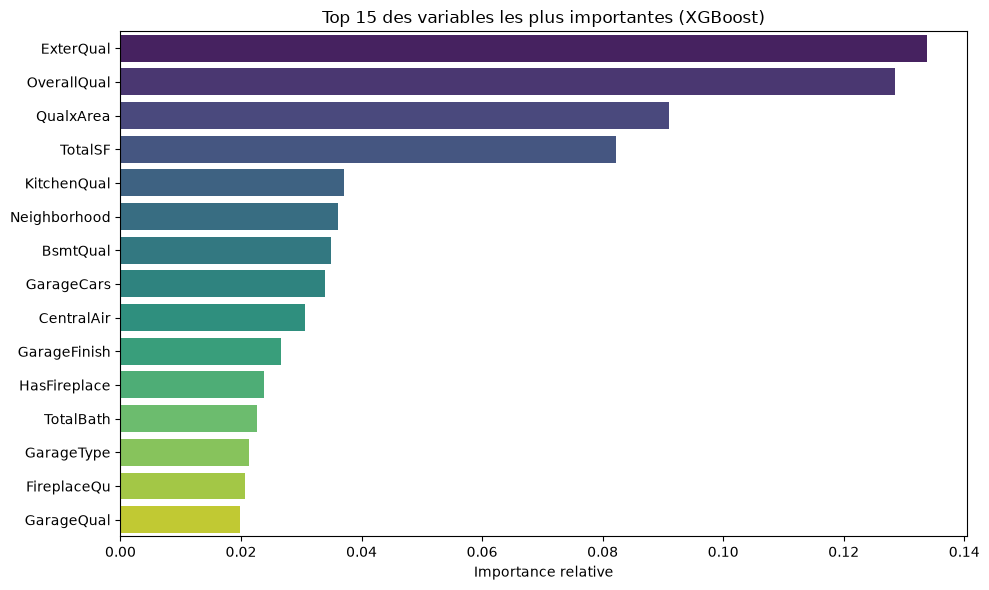

In [ ]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mathématique : RMSE (depuis Optuna)
rmse_log = study.best_value

# 2. IT : temps d'entraînement global
train_time = global_training_time

# 3. Métier : % d'écart médian sur prédictions Out-Of-Fold (sans fuite)
kf_eval = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_log = np.zeros(len(X_train))

for train_idx, val_idx in kf_eval.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pre = build_preprocessor()
    X_tr_t = pre.fit_transform(X_tr, y_tr)
    X_val_t = pre.transform(X_val)

    model_eval = XGBRegressor(
        n_estimators=final_n_estimators,
        tree_method='hist',
        random_state=42, n_jobs=-1,
        **study.best_params
    )
    model_eval.fit(X_tr_t, y_tr)
    oof_pred_log[val_idx] = model_eval.predict(X_val_t)

oof_pred_price = np.expm1(oof_pred_log)
y_train_price = np.expm1(y_train)

ecart_pct = np.abs(oof_pred_price - y_train_price) / y_train_price * 100
ecart_median = np.median(ecart_pct)

# Enregistrement de la 3ème métrique dans le Run MLflow existant
with mlflow.start_run(run_id=global_run_id):
    mlflow.log_metric("ecart_median", ecart_median)
    
    # Inférence de la signature sur les données brutes (avant preprocessing)
    signature = infer_signature(X_train, model_pipeline.predict(X_train))

    # Log le pipeline entier au format sklearn (au lieu du sous-modèle xgboost seul)
    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        signature=signature,
        input_example=X_train.head(3),
        registered_model_name="XGBoost_Ames_Housing",
        name="XGBoost_model"
    )

# Affichage des trois critères
print("=" * 50)
print("  ÉVALUATION FINALE — MODÈLE M4 XGBOOST")
print("=" * 50)
print(f"  Mathématique (RMSE Log) : {rmse_log:.5f}")
print(f"  IT (Temps entraînement) : {train_time:.2f} secondes")
print(f"  Métier (Écart médian)   : {ecart_median:.2f} %")
print("=" * 50)

# Graphique : importance des variables (Top 15)
feature_names = numeric_features + categorical_features
importances = model_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Top 15 des variables les plus importantes (XGBoost)')
plt.xlabel('Importance relative')
plt.ylabel('')
plt.tight_layout()
